# Práctica ML y DL - 02 Modelado
En este notebook probaremos diversos modelos de simulación basados en árboles:
1. `Custom Decision Tree` (Árbol de Decisión individual)
2. `RandomForestRegressor` (Bagging)
3. `GradientBoostingRegressor` (Boosting clásico)
4. `XGBRegressor` (Extreme Gradient Boosting)
5. `LGBMRegressor` (Light Gradient Boosting)

Aplicaremos One-Hot Encoding a las variables categóricas, usaremos `GridSearchCV` para buscar hiperparámetros óptimos y evaluaremos a través de validación el rendimiento de los modelos.
También **imprimiremos/graficaremos internamente la estructura de un Árbol de Decisión** para que la lógica de negocio resulte totalmente explicable.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

import warnings
warnings.filterwarnings('ignore')

# Inicializar SHAP javascript
shap.initjs()

# Configuración de los gráficos
plt.style.use('ggplot')
sns.set_palette("husl")

# Cargar los datos curados
df = pd.read_csv('data/processed_train_data.csv')
print("Dimensiones Datos Procesados:", df.shape)

# Transformar la altitud a variable continua explícitamente
df['ALTITUD'] = df['ALTITUD'].astype(float)

/home/veronica/miniforge3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dimensiones Datos Procesados: (8526, 18)


## 1. One-Hot Encoding e Imputación Final
Aplicamos variables dummy (One-Hot Encoding) a las variables categóricas evidentes en nuestro dataset.

In [2]:
# Excluimos 2022 si existiera
df = df[df['CAMPAÑA'] != 22]

categorical_cols = ['ID_ZONA', 'ID_ESTACION', 'VARIEDAD', 'MODO', 'TIPO', 'COLOR']

# Convertirlas a string temporalmente para que get_dummies actue sobre ellas
for col in categorical_cols:
    df[col] = df[col].astype(str)

# Hacemos el OHE
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Separamos Train Histórico (<= 2020) y Test (2021)
df_historico = df_encoded[df_encoded['CAMPAÑA'] <= 20].copy()
df_test = df_encoded[df_encoded['CAMPAÑA'] == 21].copy()

# Eliminar nulos en la variable objetivo del train histórico
df_historico.dropna(subset=['PRODUCCION'], inplace=True)

# Guardamos el X_test_output sin encode para recrear Mi_Solucion.txt según los ids originales
df_test_unencoded = df[df['CAMPAÑA'] == 21].copy()
X_test_output = df_test_unencoded[['ID_FINCA', 'VARIEDAD', 'MODO', 'TIPO', 'COLOR', 'SUPERFICIE']].copy()

# Features y Target totales
X_full = df_historico.drop(columns=['PRODUCCION'])
y_full = df_historico['PRODUCCION']

X_test_2021 = df_test.drop(columns=['PRODUCCION'])

# Alineamos las columnas de test con train
X_test_2021 = X_test_2021.reindex(columns=X_full.columns, fill_value=0)

# Split de validación (80% / 20%) 
X_train, X_val, y_train, y_val = train_test_split(X_full, y_full, test_size=0.2, random_state=42)
print("Tamaño del set de entrenamiento para búsqueda/evaluación OHE:", X_train.shape)
print("Tamaño del set de validación para evaluación final OHE:", X_val.shape)

Tamaño del set de entrenamiento para búsqueda/evaluación OHE: (5985, 180)
Tamaño del set de validación para evaluación final OHE: (1497, 180)


## 2. Visualización e Interpretabilidad: El Árbol de Decisión
Antes de ensayar con múltiples estimadores complejos (Random Forest / Boostings), resulta muy útil crear un modelo base compuesto por un **único Árbol de Decisión** y graficarlo. Esto nos permite entender qué reglas biológicas/físicas sigue la matemática de fondo para separar las producciones.
Lo limitaremos a `max_depth=3` puramente para que la gráfica resultante sea legible.

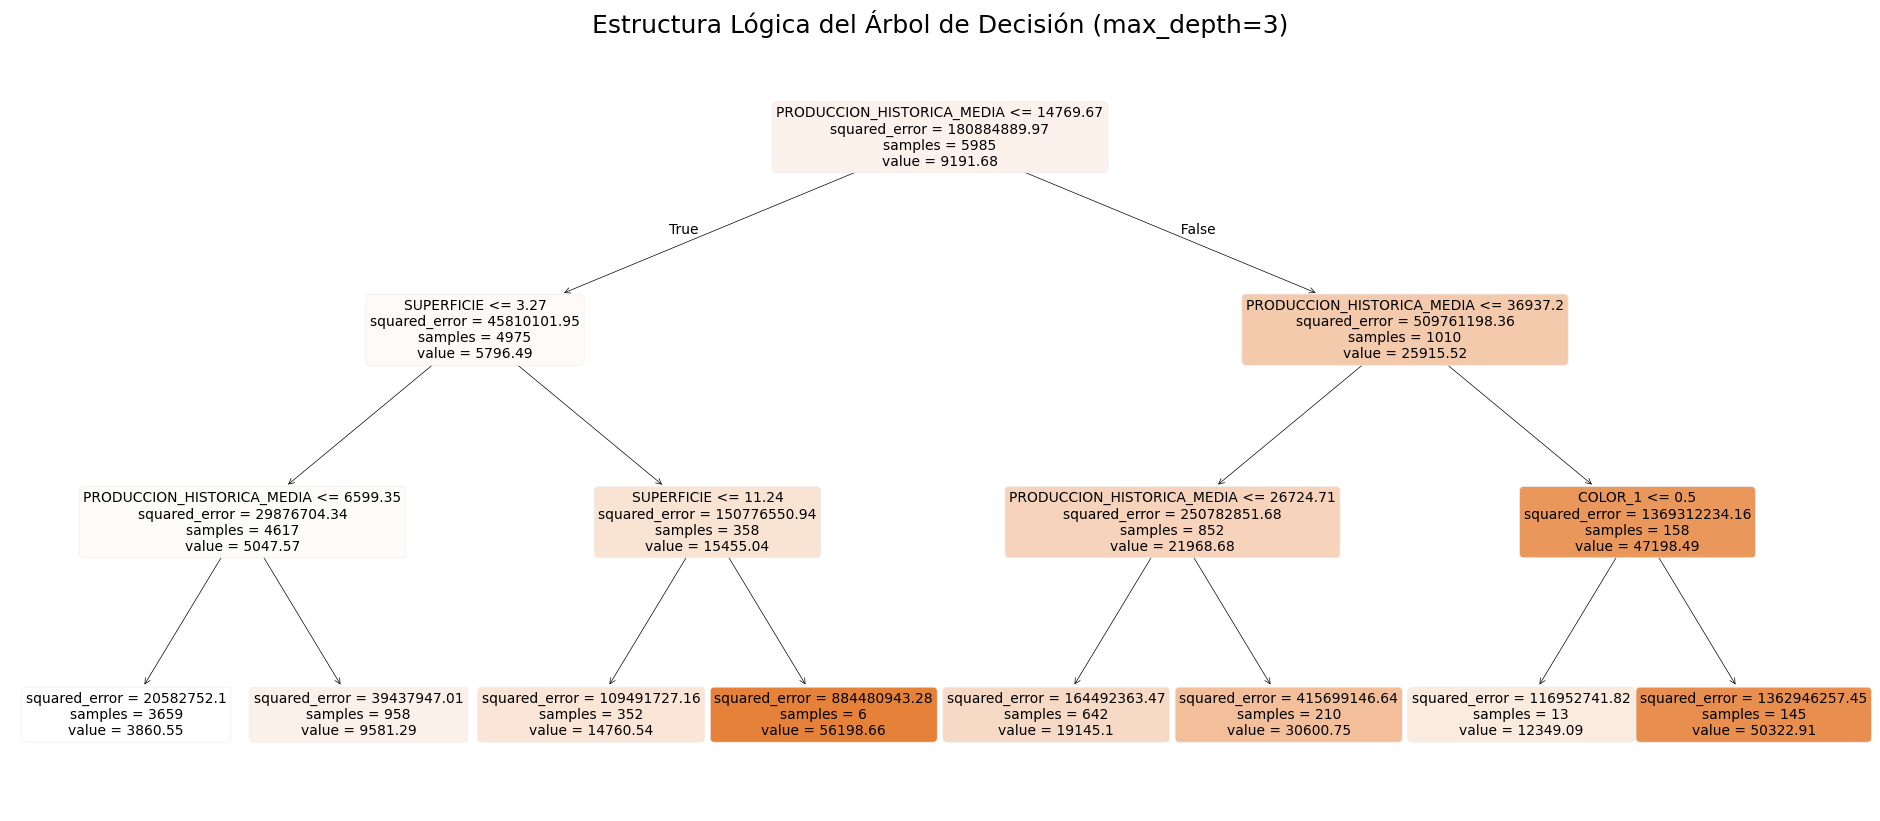

In [3]:
tree_visual = DecisionTreeRegressor(max_depth=3, random_state=42)
tree_visual.fit(X_train, y_train)

plt.figure(figsize=(24, 10))
plot_tree(tree_visual, 
          feature_names=X_train.columns, 
          filled=True, 
          rounded=True, 
          fontsize=10, 
          precision=2)
plt.title("Estructura Lógica del Árbol de Decisión (max_depth=3)", fontsize=18)
plt.show()

## 3. Búsqueda de Hiperparámetros Exhaustiva (GridSearchCV) para 5 Modelos
Para comprobar empíricamente cuál es la técnica dominante, vamos a optimizar las métricas introduciendo también un Árbol de decisión simple (`DecisionTreeRegressor`) y el `GradientBoostingRegressor` clásico de Scikit-Learn.

In [4]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

score_rmse = make_scorer(rmse, greater_is_better=False)

param_grid_dt = {
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10]
}

param_grid_rf = {
    'n_estimators': [100, 300],
    'max_depth': [10, 15]
}

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [4, 6]
}

param_grid_xgb = {
    'n_estimators': [100, 300],
    'max_depth': [4, 6],
    'learning_rate': [0.05, 0.1]
}

param_grid_lgb = {
    'n_estimators': [100, 300],
    'max_depth': [6, 10],
    'learning_rate': [0.05, 0.1]
}

# Declaramos Búsquedas

search_dt = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid=param_grid_dt, cv=3, scoring=score_rmse, n_jobs=-1)
search_rf = GridSearchCV(RandomForestRegressor(random_state=42, n_jobs=-1), param_grid=param_grid_rf, cv=3, scoring=score_rmse, n_jobs=-1)
search_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), param_grid=param_grid_gb, cv=3, scoring=score_rmse, n_jobs=-1)
search_xgb = GridSearchCV(XGBRegressor(random_state=42, n_jobs=-1), param_grid=param_grid_xgb, cv=3, scoring=score_rmse, n_jobs=-1)
search_lgb = GridSearchCV(LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1), param_grid=param_grid_lgb, cv=3, scoring=score_rmse, n_jobs=-1)


print("Buscando hiperparámetros...")
search_dt.fit(X_train, y_train)
search_rf.fit(X_train, y_train)
search_gb.fit(X_train, y_train)
search_xgb.fit(X_train, y_train)
search_lgb.fit(X_train, y_train)

best_dt = search_dt.best_estimator_
best_rf = search_rf.best_estimator_
best_gb = search_gb.best_estimator_
best_xgb = search_xgb.best_estimator_
best_lgb = search_lgb.best_estimator_

print("\nMejores hiperparámetros encontrados en validación cruzada:")
print("- Decision Tree:", search_dt.best_params_)
print("- Random Forest:", search_rf.best_params_)
print("- Gradient Boosting:", search_gb.best_params_)
print("- XGBoost:", search_xgb.best_params_)
print("- LightGBM:", search_lgb.best_params_)

Buscando hiperparámetros...



Mejores hiperparámetros encontrados en validación cruzada:
- Decision Tree: {'max_depth': 5, 'min_samples_split': 2}
- Random Forest: {'max_depth': 15, 'n_estimators': 100}
- Gradient Boosting: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200}
- XGBoost: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 300}
- LightGBM: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 300}


## 4. Visualización Avanzada (Learning Curves y Feature Importance)

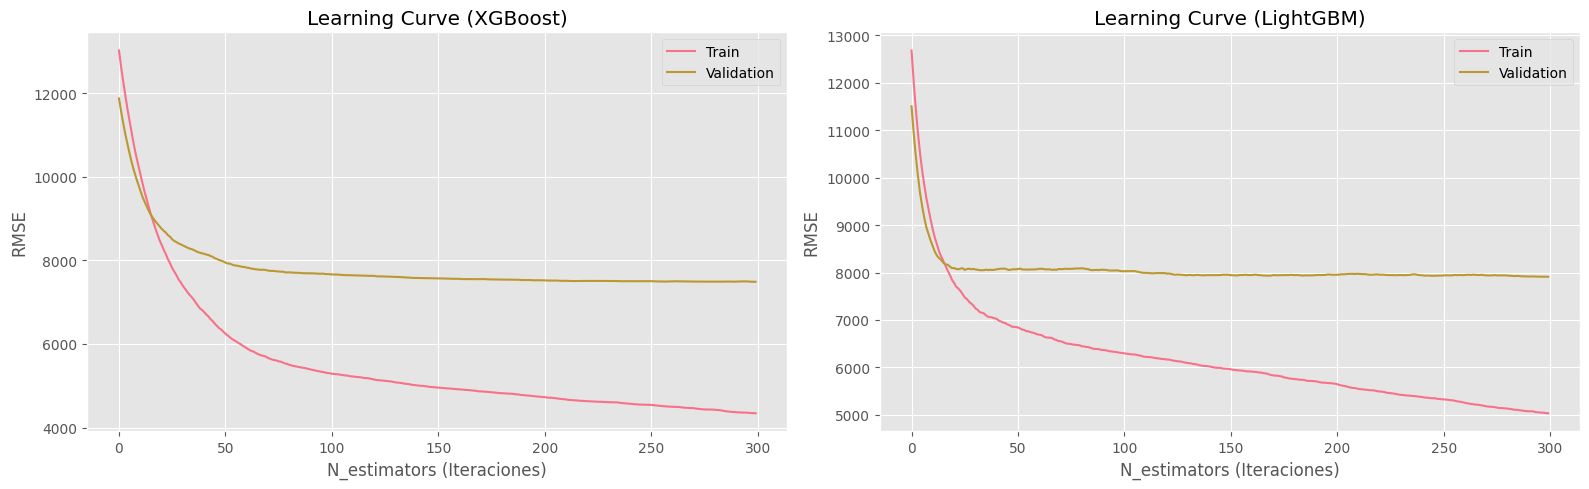

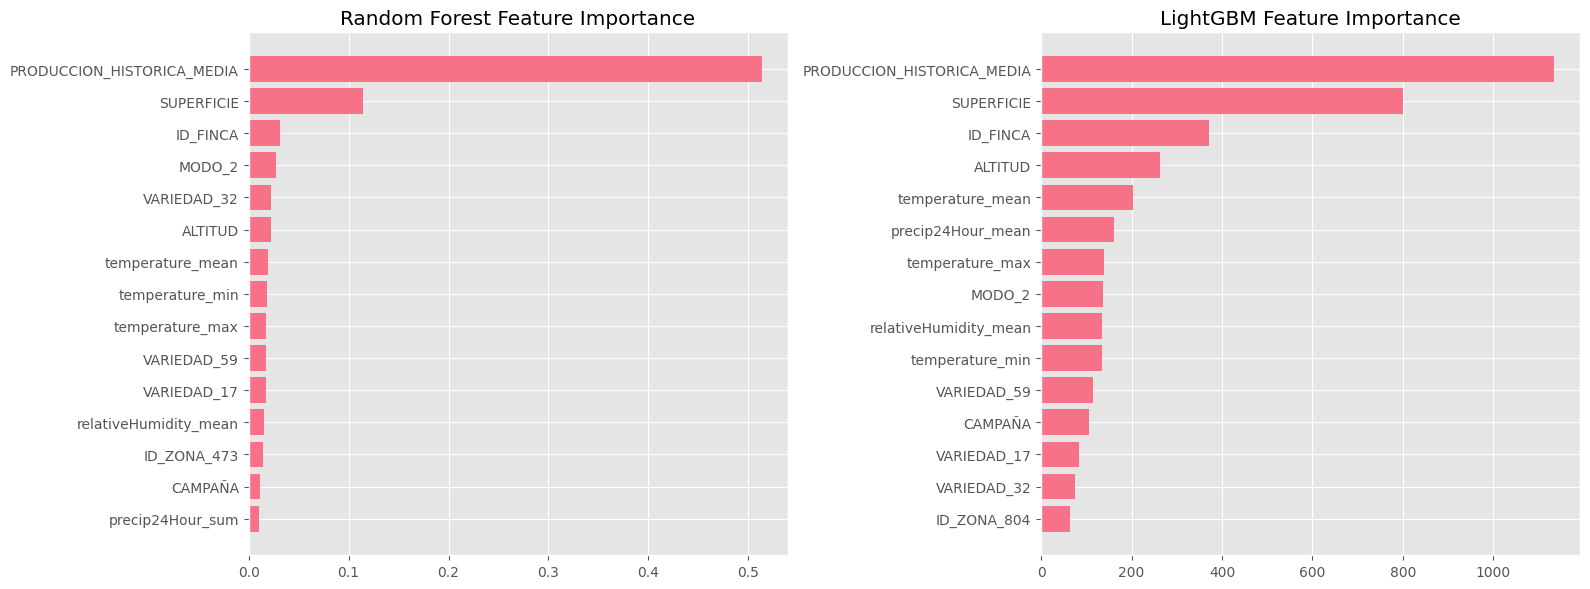

In [5]:
# --- Curvas de Aprendizaje (Learning Curves) ---
# XGBoost
xgb_eval = XGBRegressor(**search_xgb.best_params_, random_state=42, n_jobs=-1)
xgb_eval.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
resultados_xgb = xgb_eval.evals_result_

# LightGBM
lgb_eval = LGBMRegressor(**search_lgb.best_params_, random_state=42, n_jobs=-1, verbose=-1)
lgb_eval.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_val, y_val)])
resultados_lgb = lgb_eval.evals_result_

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot XGBoost
epochs_xgb = len(resultados_xgb['validation_0']['rmse'])
x_axis_xgb = range(0, epochs_xgb)
axes[0].plot(x_axis_xgb, resultados_xgb['validation_0']['rmse'], label='Train')
axes[0].plot(x_axis_xgb, resultados_xgb['validation_1']['rmse'], label='Validation')
axes[0].legend()
axes[0].set_ylabel('RMSE')
axes[0].set_xlabel('N_estimators (Iteraciones)')
axes[0].set_title('Learning Curve (XGBoost)')

# Plot LightGBM
epochs_lgb = len(resultados_lgb['training']['l2']) 
x_axis_lgb = range(0, epochs_lgb)
axes[1].plot(x_axis_lgb, np.sqrt(resultados_lgb['training']['l2']), label='Train')
axes[1].plot(x_axis_lgb, np.sqrt(resultados_lgb['valid_1']['l2']), label='Validation')
axes[1].legend()
axes[1].set_ylabel('RMSE')
axes[1].set_xlabel('N_estimators (Iteraciones)')
axes[1].set_title('Learning Curve (LightGBM)')

plt.tight_layout()
plt.show()

# --- Feature Importance ---
# Graficaremos LightGBM y RandomForest
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

def plot_importance(model, title, ax):
    if hasattr(model, 'feature_importances_'):
        importances = model.feature_importances_
    else:
        importances = np.zeros(len(X_train.columns))
    
    indices = np.argsort(importances)[-15:]
    ax.barh(range(len(indices)), importances[indices], align='center')
    ax.set_yticks(range(len(indices)), [X_train.columns[i] for i in indices])
    ax.set_title(title)

plot_importance(best_rf, 'Random Forest Feature Importance', axes[0])
plot_importance(best_lgb, 'LightGBM Feature Importance', axes[1])

plt.tight_layout()
plt.show()

## 4.5 AutoGluon AutoML
Autogluon es un framework avanzado que abstrae todo el pipeline de modelado entrenando automáticamente decenas de modelos potentes (incluyendo combinaciones, apilados, redes neuronales, etc.).

In [6]:
# Es importante asegurar la variable objetivo y juntar X e y por exigencias de Autogluon
import warnings
warnings.filterwarnings('ignore')

try:
    from autogluon.tabular import TabularPredictor
    
    # AutoGluon necesita el dataframe completo (Features + Target)
    df_ag_train = X_train.copy()
    df_ag_train['PRODUCCION'] = y_train
    
    df_ag_val = X_val.copy()
    df_ag_val['PRODUCCION'] = y_val
    
    # Definimos el predictor (optimiza por RMSE, evitamos que demore más de 120s por rapidez)
    predictor = TabularPredictor(label='PRODUCCION', eval_metric='root_mean_squared_error').fit(
        train_data=df_ag_train, 
        tuning_data=df_ag_val,
        time_limit=120,
        presets='medium_quality'
    )
    
    # Leaderboard de los mejores modelos internamente hallados por AutoGluon
    print("\n--- Leaderboard de AutoGluon ---")
    leaderboard = predictor.leaderboard(df_ag_val)
    
    # Extraemos predicciones
    ag_preds = predictor.predict(X_val)
    print(f"AutoGluon Validation RMSE: {rmse(y_val, ag_preds)}")
    
    # Añadimos sus predicciones al DataFrame global del ensamble
    if 'predicciones_val' not in globals():
        predicciones_val = {}
    if 'modelos_sintonizados' not in globals():
        modelos_sintonizados = {}
    if 'predicciones_val' not in globals():
        predicciones_val = {}
    if 'modelos_sintonizados' not in globals():
        modelos_sintonizados = {}
    predicciones_val['AutoGluon'] = ag_preds
    modelos_sintonizados['AutoGluon'] = predictor
    
except ImportError:
    print("AutoGluon no está instalado en este entorno. Usa: pip install autogluon")


AutoGluon no está instalado en este entorno. Usa: pip install autogluon


## 5. Analisis SHAP (LightGBM)
Usaremos valores **SHAP** sobre el mejor ajuste de LightGBM para interpretar en qué dirección influyen las variables.

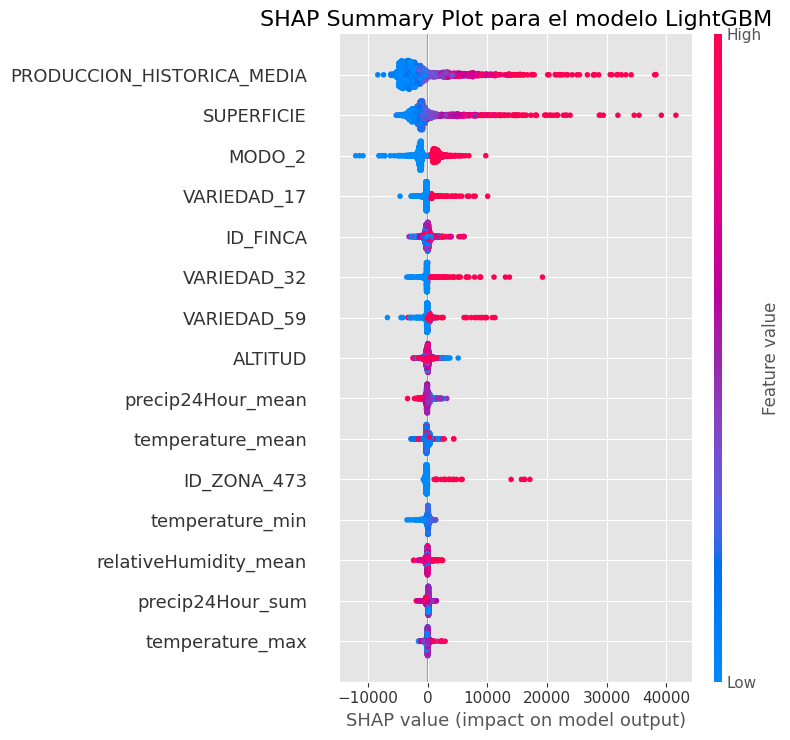

In [7]:
# Calcular SHAP values en la validación
explainer = shap.Explainer(best_lgb)
shap_values = explainer(X_val)

# El summary plot estándar con los "colores" reflejando impacto direccional
plt.figure(figsize=(10,6))
plt.title("SHAP Summary Plot para el modelo LightGBM", fontsize=16)
shap.summary_plot(shap_values, X_val, max_display=15)
plt.show()

## 6. Evaluación de Modelos y Ensamblado Final
Evaluamos los cinco modelos en el set de validación e introducimos el `VotingRegressor`, integrando los algoritmos de ensamblado más estables (RandomForest, GBM, XGB, LGB).

In [8]:
if 'modelos_sintonizados' not in locals():
    modelos_sintonizados = {}
modelos_sintonizados.update({
    'Decision Tree': best_dt,
    'Gradient Boosting': best_gb,
    'RandomForest': best_rf,
    'XGBoost': best_xgb,
    'LightGBM': best_lgb
})

resultados = []
if 'predicciones_val' not in locals():
    predicciones_val = {}

for nombre, modelo in modelos_sintonizados.items():
    preds = modelo.predict(X_val)
    preds = np.maximum(preds, 0)
    predicciones_val[nombre] = preds
    
    resultados.append({
        'Modelo': nombre,
        'RMSE': rmse(y_val, preds),
        'MAE': mean_absolute_error(y_val, preds),
        'R2': r2_score(y_val, preds)
    })

print("Entrenando Ensamblado (VotingRegressor)...")
ensemble_val = VotingRegressor([
    ('rf', best_rf),
    ('gb', best_gb),
    ('xgb', best_xgb),
    ('lgb', best_lgb)
])
ensemble_val.fit(X_train, y_train)

preds_ens = ensemble_val.predict(X_val)
preds_ens = np.maximum(preds_ens, 0)
predicciones_val['Ensamblado'] = preds_ens

resultados.append({
    'Modelo': 'Ensamblado (RF+GB+XGB+LGB)',
    'RMSE': rmse(y_val, preds_ens),
    'MAE': mean_absolute_error(y_val, preds_ens),
    'R2': r2_score(y_val, preds_ens)
})

df_resultados = pd.DataFrame(resultados).sort_values(by="RMSE")
display(df_resultados)

Entrenando Ensamblado (VotingRegressor)...


,Modelo,RMSE,MAE,R2
5,Ensamblado (RF+GB+XGB+LGB),7420.103804,3960.463631,0.630612
3,XGBoost,7489.666996,4007.001331,0.623654
1,Gradient Boosting,7621.836883,3971.958671,0.610254
2,RandomForest,7729.915983,4068.527861,0.599122
4,LightGBM,7910.059379,4207.160664,0.580220
0,Decision Tree,9415.587854,5024.135149,0.405218


## 7. Gráficas Comparativas Globales y Análisis de Residuos

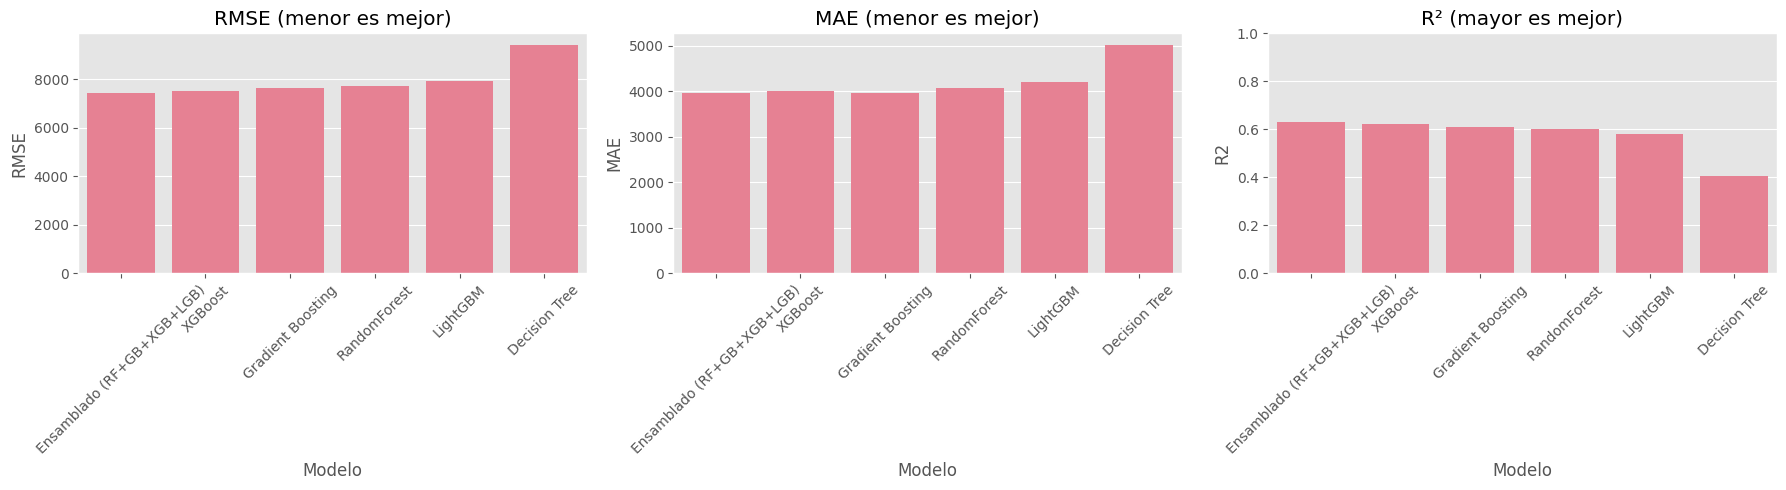

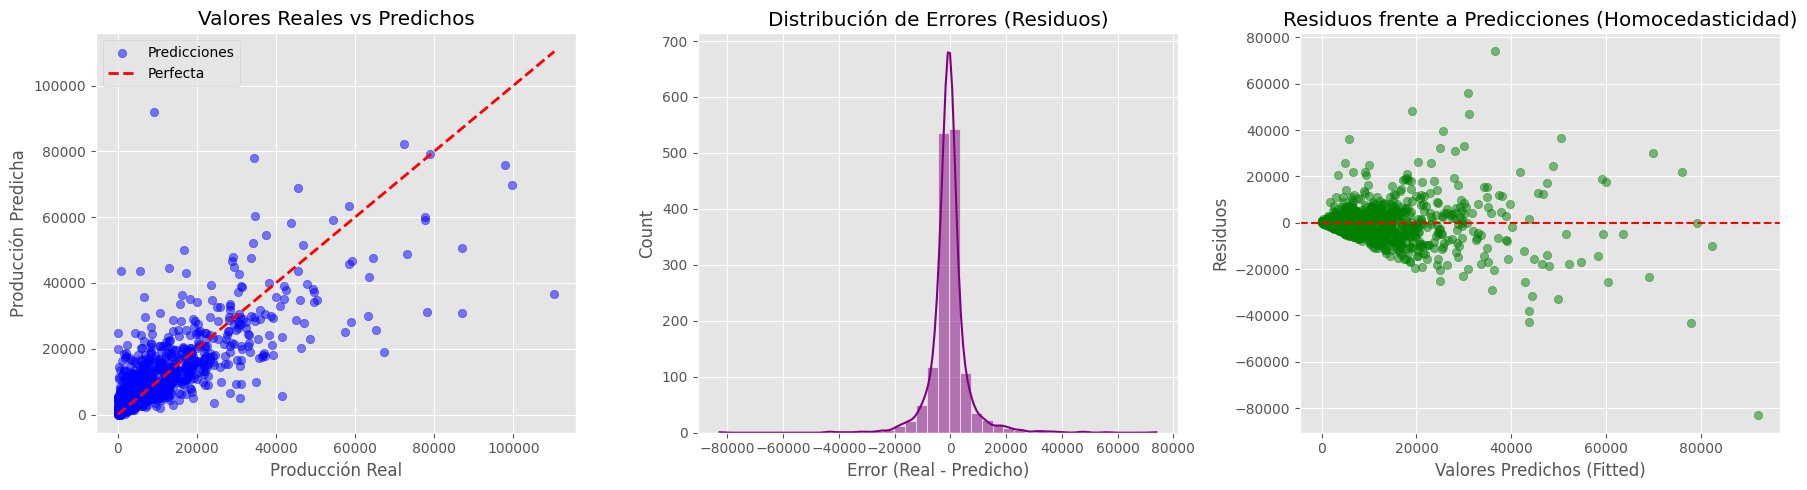

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(data=df_resultados, x='Modelo', y='RMSE', ax=axes[0])
axes[0].set_title('RMSE (menor es mejor)')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=df_resultados, x='Modelo', y='MAE', ax=axes[1])
axes[1].set_title('MAE (menor es mejor)')
axes[1].tick_params(axis='x', rotation=45)

sns.barplot(data=df_resultados, x='Modelo', y='R2', ax=axes[2])
axes[2].set_title('R² (mayor es mejor)')
axes[2].set_ylim(0, 1)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# --- Análisis de Residuos para el Ensamblado ---
residuos = y_val - predicciones_val['Ensamblado']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Scatter Real vs Predicha
axes[0].scatter(y_val, predicciones_val['Ensamblado'], alpha=0.5, color='blue', label='Predicciones')
axes[0].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2, label='Perfecta')
axes[0].set_xlabel('Producción Real')
axes[0].set_ylabel('Producción Predicha')
axes[0].set_title('Valores Reales vs Predichos')
axes[0].legend()

# Histograma de Residuos
sns.histplot(residuos, bins=40, kde=True, ax=axes[1], color='purple')
axes[1].set_title('Distribución de Errores (Residuos)')
axes[1].set_xlabel('Error (Real - Predicho)')

# Residuos vs Fitted
axes[2].scatter(predicciones_val['Ensamblado'], residuos, alpha=0.5, color='green')
axes[2].axhline(0, color='r', linestyle='--')
axes[2].set_xlabel('Valores Predichos (Fitted)')
axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos frente a Predicciones (Homocedasticidad)')

plt.tight_layout()
plt.show()

## 8. Exportación Final (Campaña 2021)
Re-entrenamos el ensemble con `X_full` para maximizar el uso del histórico y emitir la predicción de la campaña de 2021.

In [10]:
model_rf_final = RandomForestRegressor(**search_rf.best_params_, random_state=42, n_jobs=-1)
model_gb_final = GradientBoostingRegressor(**search_gb.best_params_, random_state=42)
model_xgb_final = XGBRegressor(**search_xgb.best_params_, random_state=42, n_jobs=-1)
model_lgb_final = LGBMRegressor(**search_lgb.best_params_, random_state=42, n_jobs=-1, verbose=-1)

print("Reentrenando en todo el histórico completo...")
ensemble_final = VotingRegressor([
    ('rf', model_rf_final),
    ('gb', model_gb_final),
    ('xgb', model_xgb_final),
    ('lgb', model_lgb_final)
])
ensemble_final.fit(X_full, y_full)

# Predicción 2021
y_pred_2021 = ensemble_final.predict(X_test_2021)
y_pred_2021 = np.maximum(y_pred_2021, 0)

# Preparar DataFrame de respuesta
df_res = X_test_output.copy()
df_res['PRODUCCION'] = y_pred_2021

# Para asegurar el ordenamiento correcto
df_res['VARIEDAD'] = pd.to_numeric(df_res['VARIEDAD'])
df_res['MODO'] = pd.to_numeric(df_res['MODO'])
df_res['TIPO'] = pd.to_numeric(df_res['TIPO'])
df_res['COLOR'] = pd.to_numeric(df_res['COLOR'])

cols_sort = ['ID_FINCA', 'VARIEDAD', 'MODO', 'TIPO', 'COLOR', 'SUPERFICIE']
df_res.sort_values(by=cols_sort, ascending=True, inplace=True)

df_res['PRODUCCION'] = df_res['PRODUCCION'].round(2)

print("Filas del dataframe generado:", df_res.shape[0])

# Guardar a txt sin cabecera y con separador ;
df_res.to_csv('Mi_Solucion.txt', sep=';', index=False, header=False)
print("Se ha generado Mi_Solucion.txt exitosamente.")

Reentrenando en todo el histórico completo...


Filas del dataframe generado: 1044
Se ha generado Mi_Solucion.txt exitosamente.
